In [1]:
import random
import numpy as np
import torch

# Set random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Importing reqired Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

#### Loading the dataset

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv( #used to read the CSV file from the specified URL and load it into a DataFrame
    url,
    sep=';',
    header=None
)

print(data.shape)
print("Dataset loaded successfully!")

(1055, 42)
Dataset loaded successfully!


#### Pre-processing the data by removing duplicats

In [4]:
print("Before:", data.shape)

data = data.drop_duplicates()

print("After :", data.shape)

Before: (1055, 42)
After : (1052, 42)


#### Splitting targets and descriptors

In [5]:
X = data.iloc[:, :-1]

y = data.iloc[:, -1]

print("Features :", X.shape)
print("Labels   :", y.shape)

Features : (1052, 41)
Labels   : (1052,)


#### Encoding Labels for Readily Biodegradable (RB) & Not- Readily Biodegradable (NRB)

In [6]:
y = y.str.strip()

y = y.map({
    "RB": 1,
    "NRB": 0
})

print(y.value_counts())

41
0    698
1    354
Name: count, dtype: int64


#### Scaling the dataset

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1052, 41)


#### Applying PCA to the dataset

Original shape : (1052, 41)
PCA shape      : (1052, 10)


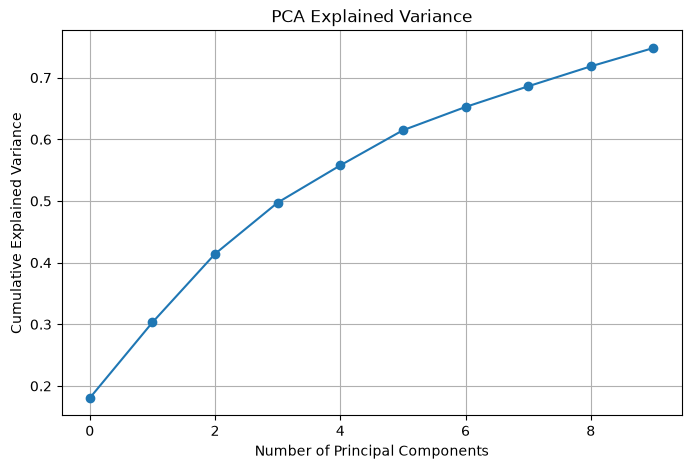

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Create PCA object
pca = PCA(
    n_components=10,
    random_state=SEED
)

# Fit PCA and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# Check the new shape
print("Original shape :", X_scaled.shape)
print("PCA shape      :", X_pca.shape)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

#### Explains why only 10 features were reduced through PCA

In [9]:
# Explained variance of each principal component
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Display results
for i, var in enumerate(cumulative_variance):
    print(f"PC {i+1}: {var:.4f}")

PC 1: 0.1805
PC 2: 0.3031
PC 3: 0.4142
PC 4: 0.4974
PC 5: 0.5578
PC 6: 0.6147
PC 7: 0.6525
PC 8: 0.6860
PC 9: 0.7184
PC 10: 0.7481


The first 10 principal components retained more than 74% of the total variance. Therefore, these 22 components were selected as the input to the quantum model.

#### The next step saves the PCA dataset to use it in quantum model.

In [10]:
X_pca_df = pd.DataFrame(X_pca)

X_pca_df["Target"] = y.values

X_pca_df.to_csv("biodeg_pca.csv", index=False)


#### Converting the 22 PCA features into 8 dimensional cubits for using them as input in quantom model

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ClassicalFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.Tanh()
        )

    def forward(self, x):

        x = self.network(x)

        # Normalize before amplitude embedding
        x = F.normalize(x, p=2, dim=1)

        return x

### Splitting the data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

### Convert everything to PyTorch tensors 

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

### Creating a feature extractor and passing the data through it

In [14]:
feature_extractor = ClassicalFeatureExtractor()

In [15]:
X_train_8 = feature_extractor(X_train)
X_test_8 = feature_extractor(X_test)

### Building the Quantum Neural Network (QNN)

In [16]:
import pennylane as qml

### Creating quantum device

In [17]:
n_qubits = 3
n_layers = 5

dev = qml.device("default.qubit", wires=n_qubits)

### Creating a Quantum Circuit

In [18]:
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # Encode 8 classical features into 3 qubits
    qml.AmplitudeEmbedding(
        features=inputs,
        wires=range(n_qubits),
        normalize=True
    )

    # Variational layers
    for layer in range(n_layers):

        for qubit in range(n_qubits):

            qml.RX(weights[layer, qubit, 0], wires=qubit)
            qml.RY(weights[layer, qubit, 1], wires=qubit)
            qml.RZ(weights[layer, qubit, 2], wires=qubit)

        # Ring entanglement
        qml.CNOT(wires=[0,1])
        qml.CNOT(wires=[1,2])
        qml.CNOT(wires=[2,0])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

### Assigning weights

In [19]:
weights = torch.randn(
    n_layers,
    n_qubits,
    3,
    requires_grad=True
)

### Plotting the circuit

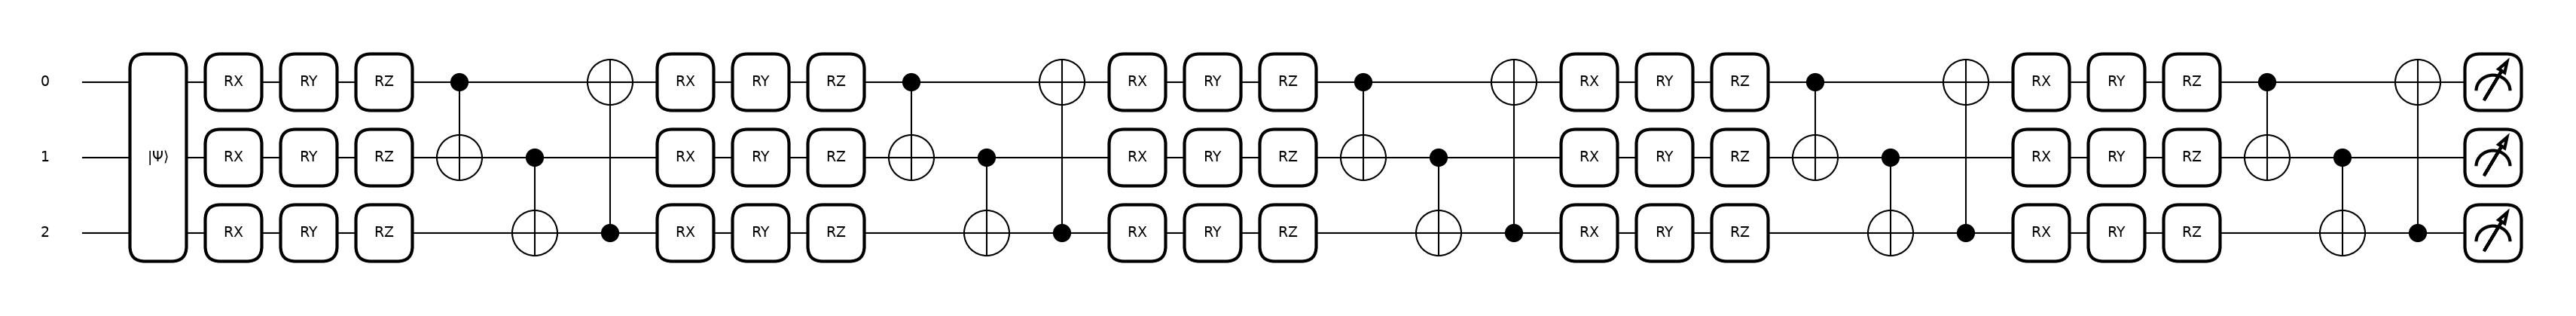

In [20]:
import matplotlib.pyplot as plt

sample = X_train_8[0]

fig, ax = qml.draw_mpl(quantum_circuit)(sample, weights)
plt.show()

The 8-dimensional output from the classical feature extractor is encoded into a 3-qubit quantum state using Amplitude Embedding. The quantum state then passes through three variational layers composed of RX, RY, and RZ rotation gates followed by CNOT entanglement. Finally, measurements are performed in the Pauli-Z basis to obtain the quantum outputs used for classification.

#### Amplitude Embedding (|ψ⟩): 
Encodes the 8 classical features into the amplitudes of a 3-qubit quantum state.

#### RX, RY, RZ Gates: 
Apply trainable rotations around the X, Y, and Z axes of the Bloch sphere, allowing the model to learn complex feature transformations.

#### CNOT Gates: 
Entangle the qubits so that the quantum model can learn relationships between different features.

#### Three Variational Layers: 
Repeating the rotation and entanglement blocks increases the expressive power of the circuit.

#### Pauli-Z Measurement: 
Measures each qubit to produce three expectation values in the range [-1, 1], which serve as the output of the quantum layer.

## Converting the circuit into torch layer

In [21]:
weight_shapes = {
    "weights": (n_layers, n_qubits, 3)
}

q_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)

#### Building the hybrid model

In [22]:
import torch.nn as nn

class HybridModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Classical Feature Extractor
        self.feature_extractor = ClassicalFeatureExtractor()

        # Quantum Layer
        self.quantum = q_layer

        # Final Classifier
        self.classifier = nn.Linear(3, 2)

    def forward(self, x):

        x = self.feature_extractor(x)

        x = self.quantum(x)

        x = self.classifier(x)

        return x

#### Creating the model

In [23]:
model = HybridModel()

print(model)

HybridModel(
  (feature_extractor): ClassicalFeatureExtractor(
    (network): Sequential(
      (0): Linear(in_features=10, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=8, bias=True)
      (3): Tanh()
    )
  )
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Linear(in_features=3, out_features=2, bias=True)
)


#### Testing the model

In [24]:
sample = X_train[:5]

output = model(sample)

print(output.shape)
print(output)

torch.Size([5, 2])
tensor([[-0.3545, -0.3351],
        [-0.3049, -0.4635],
        [-0.5182, -0.3619],
        [-0.1281, -0.8031],
        [-0.5327, -0.4052]], grad_fn=<AddmmBackward0>)


### Performing binary classification

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

epochs = 200

train_loss_history = []
train_accuracy_history = []

#### Training loop

In [26]:
for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    predictions = torch.argmax(outputs, dim=1)

    accuracy = (predictions == y_train).float().mean()

    train_loss_history.append(loss.item())
    train_accuracy_history.append(accuracy.item())
    
    if (epoch + 1) % 50 == 0:
        print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {loss.item():.4f} "
        f"Accuracy: {accuracy.item()*100:.2f}%"
    )
       

Epoch [50/200] Loss: 0.2530 Accuracy: 90.49%
Epoch [100/200] Loss: 0.1658 Accuracy: 94.05%
Epoch [150/200] Loss: 0.1241 Accuracy: 95.96%
Epoch [200/200] Loss: 0.1054 Accuracy: 96.43%


#### Checking the final accuracy

In [27]:
model.eval()

with torch.no_grad():

    outputs = model(X_train)

    predictions = torch.argmax(outputs, dim=1)

    accuracy = (predictions == y_train).float().mean()

print(f"Training Accuracy: {accuracy*100:.2f}%")

Training Accuracy: 96.55%


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt
import numpy as np

In [29]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    probabilities = torch.softmax(outputs, dim=1)

    predictions = torch.argmax(outputs, dim=1)

In [30]:
y_true = y_test.cpu().numpy()

y_pred = predictions.cpu().numpy()

y_prob = probabilities[:,1].cpu().numpy()

In [31]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

auc = roc_auc_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred)

In [32]:
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

In [33]:
print(f"Accuracy    : {accuracy:.4f}")

print(f"Precision   : {precision:.4f}")

print(f"Recall      : {recall:.4f}")

print(f"F1 Score    : {f1:.4f}")

print(f"Specificity : {specificity:.4f}")

print(f"ROC AUC     : {auc:.4f}")

Accuracy    : 0.8910
Precision   : 0.8750
Recall      : 0.7887
F1 Score    : 0.8296
Specificity : 0.9429
ROC AUC     : 0.9245


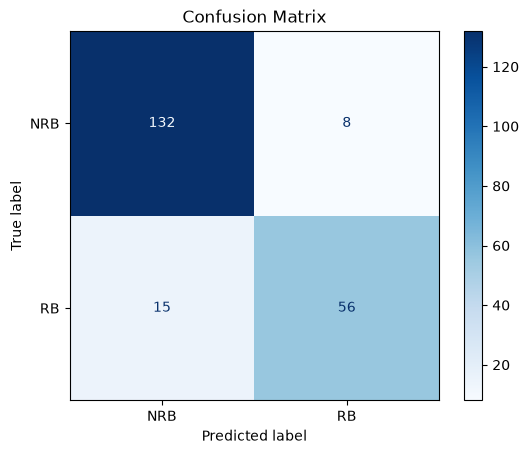

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NRB", "RB"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

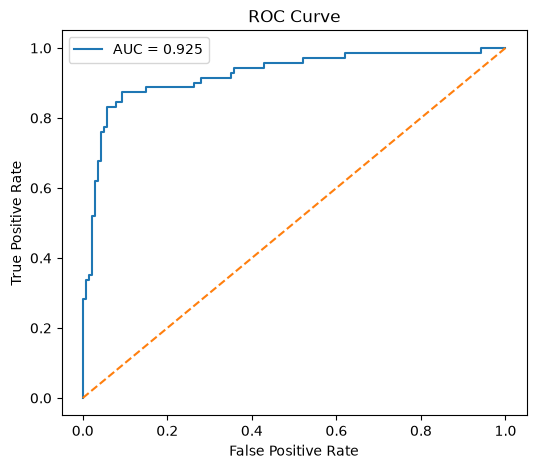

In [35]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()